In [1]:
# CELL 1: Imports (run this FIRST, every session)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import warnings
warnings.filterwarnings('ignore')
print("Libraries imported successfully")
print("pandas:", pd.__version__)
print("numpy:", np.__version__)


Libraries imported successfully
pandas: 2.2.2
numpy: 2.0.2


In [2]:
# CELL 2: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# CELL 3: Load PaySim from Drive
# Update the path to match exactly where your file is in Drive
df = pd.read_csv('/content/drive/MyDrive/Project/PS_20174392719_1491204439457_log.csv')
print("=== PaySim Dataset Loaded ===")
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 3 rows:")
print(df.head(3))

=== PaySim Dataset Loaded ===
Shape: (6362620, 11)

Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

First 3 rows:
   step      type   amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT  9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT  1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER   181.00  C1305486145          181.0            0.00   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  


In [4]:
# CELL 4: Explore fraud rate and transaction types
print("=== Fraud Rate ===")
print(df['isFraud'].value_counts())
print(f"\nFraud rate: {df['isFraud'].mean()*100:.4f}%")
print(f"Total fraud transactions: {df['isFraud'].sum():,}")
print(f"Total transactions: {len(df):,}")

print("\n=== Fraud by Transaction Type ===")
fraud_by_type = df.groupby('type')['isFraud'].agg(['sum','mean','count'])
fraud_by_type.columns = ['fraud_count','fraud_rate','total']
print(fraud_by_type)
print("\nKey finding: Fraud ONLY occurs in CASH_OUT and TRANSFER types")

=== Fraud Rate ===
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud rate: 0.1291%
Total fraud transactions: 8,213
Total transactions: 6,362,620

=== Fraud by Transaction Type ===
          fraud_count  fraud_rate    total
type                                      
CASH_IN             0    0.000000  1399284
CASH_OUT         4116    0.001840  2237500
DEBIT               0    0.000000    41432
PAYMENT             0    0.000000  2151495
TRANSFER         4097    0.007688   532909

Key finding: Fraud ONLY occurs in CASH_OUT and TRANSFER types


In [5]:
# CELL 5: Filter to relevant transaction types
df_filtered = df[df['type'].isin(['CASH_OUT', 'TRANSFER'])].copy()
df_filtered = df_filtered.sort_values(['nameOrig', 'step']).reset_index(drop=True)

print("=== After Filtering ===")
print(f"Original rows: {len(df):,}")
print(f"After filtering to CASH_OUT + TRANSFER: {len(df_filtered):,}")
print(f"Rows removed: {len(df) - len(df_filtered):,}")
print(f"New fraud rate: {df_filtered['isFraud'].mean()*100:.4f}%")
print(f"Fraud transactions kept: {df_filtered['isFraud'].sum():,}")

=== After Filtering ===
Original rows: 6,362,620
After filtering to CASH_OUT + TRANSFER: 2,770,409
Rows removed: 3,592,211
New fraud rate: 0.2965%
Fraud transactions kept: 8,213


In [6]:
# CELL 6: Basic statistics
print("=== Amount Statistics (Fraud vs Normal) ===")
print(df_filtered.groupby('isFraud')['amount'].describe().round(2))

print("\n=== Balance Change Analysis ===")
df_filtered['balance_change_orig'] = df_filtered['newbalanceOrig'] - df_filtered['oldbalanceOrg']
print("Average balance change for FRAUD transactions:")
print(f"  {df_filtered[df_filtered['isFraud']==1]['balance_change_orig'].mean():.2f}")
print("Average balance change for NORMAL transactions:")
print(f"  {df_filtered[df_filtered['isFraud']==0]['balance_change_orig'].mean():.2f}")

=== Amount Statistics (Fraud vs Normal) ===
             count       mean         std   min        25%        50%  \
isFraud                                                                 
0        2762196.0   314115.5   877144.15  0.01   82908.23  171034.46   
1           8213.0  1467967.3  2404252.95  0.00  127091.33  441423.44   

                75%          max  
isFraud                           
0         305994.18  92445516.64  
1        1517771.48  10000000.00  

=== Balance Change Analysis ===
Average balance change for FRAUD transactions:
  -1457274.97
Average balance change for NORMAL transactions:
  -27311.99


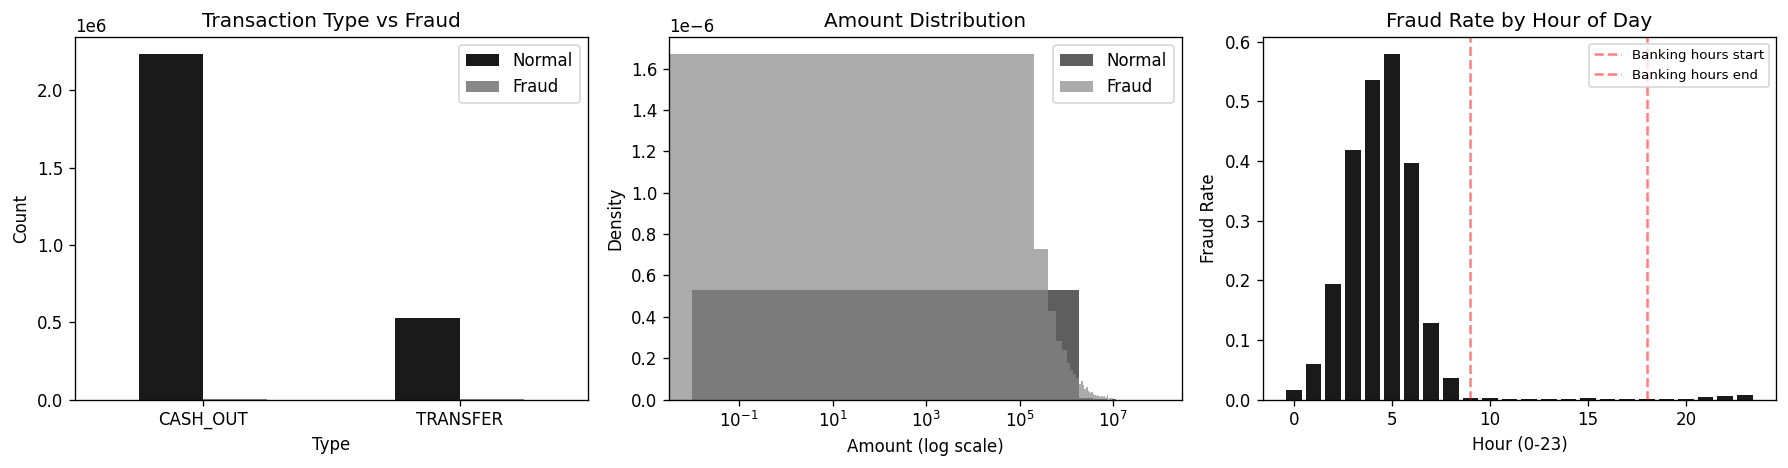

Plot saved as eda_fraud_distribution.png


In [7]:
# CELL 7: Visualise fraud distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

type_counts = df_filtered.groupby(['type', 'isFraud']).size().unstack(fill_value=0)
type_counts.plot(kind='bar', ax=axes[0], color=['#1a1a1a','#888888'])
axes[0].set_title('Transaction Type vs Fraud')
axes[0].set_xlabel('Type')
axes[0].set_ylabel('Count')
axes[0].legend(['Normal', 'Fraud'])
axes[0].tick_params(axis='x', rotation=0)

axes[1].hist(df_filtered[df_filtered['isFraud']==0]['amount'],
             bins=50, alpha=0.7, color='#1a1a1a', label='Normal', density=True)
axes[1].hist(df_filtered[df_filtered['isFraud']==1]['amount'],
             bins=50, alpha=0.7, color='#888888', label='Fraud', density=True)
axes[1].set_title('Amount Distribution')
axes[1].set_xlabel('Amount (log scale)')
axes[1].set_ylabel('Density')
axes[1].set_xscale('log')
axes[1].legend()

df_filtered['hour'] = df_filtered['step'] % 24
hour_fraud = df_filtered.groupby('hour')['isFraud'].mean()
axes[2].bar(hour_fraud.index, hour_fraud.values, color='#1a1a1a')
axes[2].set_title('Fraud Rate by Hour of Day')
axes[2].set_xlabel('Hour (0-23)')
axes[2].set_ylabel('Fraud Rate')
axes[2].axvline(x=9, color='red', linestyle='--', alpha=0.5, label='Banking hours start')
axes[2].axvline(x=18, color='red', linestyle='--', alpha=0.5, label='Banking hours end')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('eda_fraud_distribution.png', bbox_inches='tight')
plt.show()
print("Plot saved as eda_fraud_distribution.png")

In [8]:
# CELL 8: Add Irish CBI Feature 1 - Amount Ratio
# CBI reports average Irish P2P transfer is 65 euros (CBI Payment Fraud Statistics 2024)
CBI_AVERAGE_P2P = 65.0
df_filtered['amount_ratio'] = df_filtered['amount'] / CBI_AVERAGE_P2P

print("=== Feature 1: amount_ratio ===")
print("Formula: transaction amount / CBI Irish P2P average (65 euros)")
print(f"\nAmount ratio statistics:")
print(df_filtered['amount_ratio'].describe().round(2))
print(f"\nAverage amount_ratio for FRAUD: {df_filtered[df_filtered['isFraud']==1]['amount_ratio'].mean():.1f}x")
print(f"Average amount_ratio for NORMAL: {df_filtered[df_filtered['isFraud']==0]['amount_ratio'].mean():.1f}x")

=== Feature 1: amount_ratio ===
Formula: transaction amount / CBI Irish P2P average (65 euros)

Amount ratio statistics:
count    2770409.00
mean        4885.17
std        13658.30
min            0.00
25%         1276.52
50%         2634.78
75%         4719.86
max      1422238.72
Name: amount_ratio, dtype: float64

Average amount_ratio for FRAUD: 22584.1x
Average amount_ratio for NORMAL: 4832.5x


In [9]:
# CELL 9: Add Irish CBI Feature 2 - Time of Day Anomaly
# CBI seasonal data shows Irish banking activity 09:00-18:00 weekdays
df_filtered['outside_hours'] = (
    (df_filtered['hour'] < 9) | (df_filtered['hour'] > 18)
).astype(int)

print("=== Feature 2: outside_hours ===")
print("Formula: 1 if transaction before 9am or after 6pm, else 0")
print(f"\nTransactions outside hours: {df_filtered['outside_hours'].sum():,}")
print(f"\nFraud rate INSIDE banking hours: "
      f"{df_filtered[df_filtered['outside_hours']==0]['isFraud'].mean()*100:.4f}%")
print(f"Fraud rate OUTSIDE banking hours: "
      f"{df_filtered[df_filtered['outside_hours']==1]['isFraud'].mean()*100:.4f}%")


=== Feature 2: outside_hours ===
Formula: 1 if transaction before 9am or after 6pm, else 0

Transactions outside hours: 770,759

Fraud rate INSIDE banking hours: 0.1730%
Fraud rate OUTSIDE banking hours: 0.6167%


In [10]:
# CELL 10: Add Irish CBI Feature 3 - Velocity
# Counts prior transactions per sender - high velocity is suspicious
df_filtered['velocity_1h'] = df_filtered.groupby('nameOrig').cumcount()

print("=== Feature 3: velocity_1h ===")
print("Formula: cumulative transaction count per sender (sorted by time)")
print(f"\nVelocity statistics:")
print(df_filtered['velocity_1h'].describe().round(2))
print(f"\nAverage velocity for FRAUD: {df_filtered[df_filtered['isFraud']==1]['velocity_1h'].mean():.2f}")
print(f"Average velocity for NORMAL: {df_filtered[df_filtered['isFraud']==0]['velocity_1h'].mean():.2f}")

=== Feature 3: velocity_1h ===
Formula: cumulative transaction count per sender (sorted by time)

Velocity statistics:
count    2770409.00
mean           0.00
std            0.03
min            0.00
25%            0.00
50%            0.00
75%            0.00
max            2.00
Name: velocity_1h, dtype: float64

Average velocity for FRAUD: 0.00
Average velocity for NORMAL: 0.00


In [11]:
# CELL 11: Add Irish CBI Feature 4 - Recipient Risk Score
# New accounts receiving money = potential money mule
recipient_counts = df_filtered.groupby('nameDest').cumcount()
df_filtered['recipient_risk_score'] = (recipient_counts < 3).astype(int)

print("=== Feature 4: recipient_risk_score ===")
print("Formula: 1 if recipient has received fewer than 3 prior transactions")
print(f"\nHigh-risk recipients flagged: {df_filtered['recipient_risk_score'].sum():,}")
print(f"\nFraud rate when recipient IS high risk: "
      f"{df_filtered[df_filtered['recipient_risk_score']==1]['isFraud'].mean()*100:.4f}%")
print(f"Fraud rate when recipient is NOT high risk: "
      f"{df_filtered[df_filtered['recipient_risk_score']==0]['isFraud'].mean()*100:.4f}%")

=== Feature 4: recipient_risk_score ===
Formula: 1 if recipient has received fewer than 3 prior transactions

High-risk recipients flagged: 1,192,584

Fraud rate when recipient IS high risk: 0.4992%
Fraud rate when recipient is NOT high risk: 0.1432%


In [12]:
# CELL 12: Confirm all 4 features added
print("=== Final Feature Set ===")
new_cbi_features = ['amount_ratio','outside_hours','velocity_1h','recipient_risk_score']
print(f"New Irish CBI columns added: {new_cbi_features}")
print(f"Dataset shape with CBI features: {df_filtered.shape}")

print("\n=== Sample rows with all CBI features ===")
sample = df_filtered[['amount','amount_ratio','hour','outside_hours',
                       'velocity_1h','recipient_risk_score','isFraud']].head(5)
print(sample.to_string())

=== Final Feature Set ===
New Irish CBI columns added: ['amount_ratio', 'outside_hours', 'velocity_1h', 'recipient_risk_score']
Dataset shape with CBI features: (2770409, 17)

=== Sample rows with all CBI features ===
       amount  amount_ratio  hour  outside_hours  velocity_1h  recipient_risk_score  isFraud
0   244486.46   3761.330154     9              0            0                     1        0
1   211189.64   3249.071385    15              0            0                     1        0
2    93865.13   1444.078923    17              0            0                     1        0
3  3228390.11  49667.540154    10              0            0                     1        0
4   233109.79   3586.304462    17              0            0                     1        0


In [13]:
# CELL 13: Correlation of new features with fraud
print("=== Correlation of CBI Features with Fraud Label ===")
corr_features = ['amount_ratio','outside_hours','velocity_1h','recipient_risk_score']
for feat in corr_features:
    corr = df_filtered[feat].corr(df_filtered['isFraud'])
    print(f"  {feat}: {corr:.4f}")

print("\n=== Week 1 Complete ===")
print("Data loaded, filtered, and 4 Irish CBI features engineered.")

=== Correlation of CBI Features with Fraud Label ===
  amount_ratio: 0.0707
  outside_hours: 0.0366
  velocity_1h: 0.0012
  recipient_risk_score: 0.0324

=== Week 1 Complete ===
Data loaded, filtered, and 4 Irish CBI features engineered.


In [14]:
# CELL 14: Save processed dataset back to Drive
df_filtered.to_csv('/content/drive/MyDrive/Project/sentinelguard_processed.csv', index=False)
print("Processed dataset saved to Google Drive: sentinelguard_processed.csv")
print(f"Final shape: {df_filtered.shape}")

Processed dataset saved to Google Drive: sentinelguard_processed.csv
Final shape: (2770409, 17)
